# TF-IDF

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/kaggle/input/suicide-detection-full-cleaned-balanced-dataset/suicide_detection_full_cleaned_balanced_dataset.csv')

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print("\nSample data:")
print(df.head())

# Check for class distribution
print("\nClass distribution:")
print(df['class'].value_counts())

# Extract features and labels
X = df['cleaned_text']
y = df['class']

# Apply TF-IDF vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_tfidf = tfidf_vectorizer.fit_transform(X)

# Split the data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

# Display information about the split
print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Optional: visualize most frequent terms in the dataset
def plot_top_terms(vectorizer, top_n=20):
    feature_names = vectorizer.get_feature_names_out()
    # Sum TF-IDF values across documents for each term
    sums = X_tfidf.sum(axis=0).A1
    # Get the indices of the top terms
    top_indices = np.argsort(sums)[-top_n:]
    # Get the top terms and their TF-IDF sums
    top_terms = [feature_names[i] for i in top_indices]
    top_sums = [sums[i] for i in top_indices]
    
    # Plot
    plt.figure(figsize=(10, 8))
    plt.barh(top_terms, top_sums)
    plt.xlabel('TF-IDF Sum')
    plt.ylabel('Terms')
    plt.title(f'Top {top_n} Most Frequent Terms (TF-IDF)')
    plt.tight_layout()
    plt.show()

# Uncomment to visualize top terms
# plot_top_terms(tfidf_vectorizer)

# Now the data is ready for model training
print("\nData preparation complete. Ready for model training.")

# You can now proceed with your model training code
# For example:
"""
from sklearn.linear_model import LogisticRegression

# Train a logistic regression model
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate the model
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()
"""

Dataset shape: (195454, 3)

Sample data:
                                                text        class  \
0  remind me to never write research papers for a...  non-suicide   
1  Help me Okay, so have a HUGE crush on someone....  non-suicide   
2  Gif pfps are no more Where you were when gif p...  non-suicide   
3  Goodbye everyone!Alas, the day has come! I don...      suicide   
4  GIRLS ONLY, GUYS GET OUT Now that the horny gu...  non-suicide   

                                        cleaned_text  
0  remind never write research paper living term ...  
1  help okay huge crush not talk though time clos...  
2  pop no pop stop move home eat dorito phone rin...  
3  goodbye alas day come not feel super upset lit...  
4  girl guy horny guy not hate pee think cock pan...  

Class distribution:
class
non-suicide    97727
suicide        97727
Name: count, dtype: int64

Training set shape: (156363, 10000)
Testing set shape: (39091, 10000)

Data preparation complete. Ready for model trai

'\nfrom sklearn.linear_model import LogisticRegression\n\n# Train a logistic regression model\nclf = LogisticRegression(max_iter=1000, random_state=42)\nclf.fit(X_train, y_train)\n\n# Make predictions\ny_pred = clf.predict(X_test)\n\n# Evaluate the model\nprint("\nClassification Report:")\nprint(classification_report(y_test, y_pred))\n\n# Plot confusion matrix\ncm = confusion_matrix(y_test, y_pred)\nplt.figure(figsize=(8, 6))\nsns.heatmap(cm, annot=True, fmt=\'d\', cmap=\'Blues\', cbar=False,\n            xticklabels=clf.classes_, yticklabels=clf.classes_)\nplt.xlabel(\'Predicted\')\nplt.ylabel(\'Actual\')\nplt.title(\'Confusion Matrix\')\nplt.tight_layout()\nplt.show()\n'

# Logistic Regression

Training Logistic Regression model...
Model training complete.

Model Evaluation Metrics:
Accuracy: 0.9286
Precision: 0.9358
Recall: 0.9202
F1-score: 0.9279
AUC-ROC: 0.9783

Classification Report:
              precision    recall  f1-score   support

 non-suicide       0.92      0.94      0.93     19546
     suicide       0.94      0.92      0.93     19545

    accuracy                           0.93     39091
   macro avg       0.93      0.93      0.93     39091
weighted avg       0.93      0.93      0.93     39091



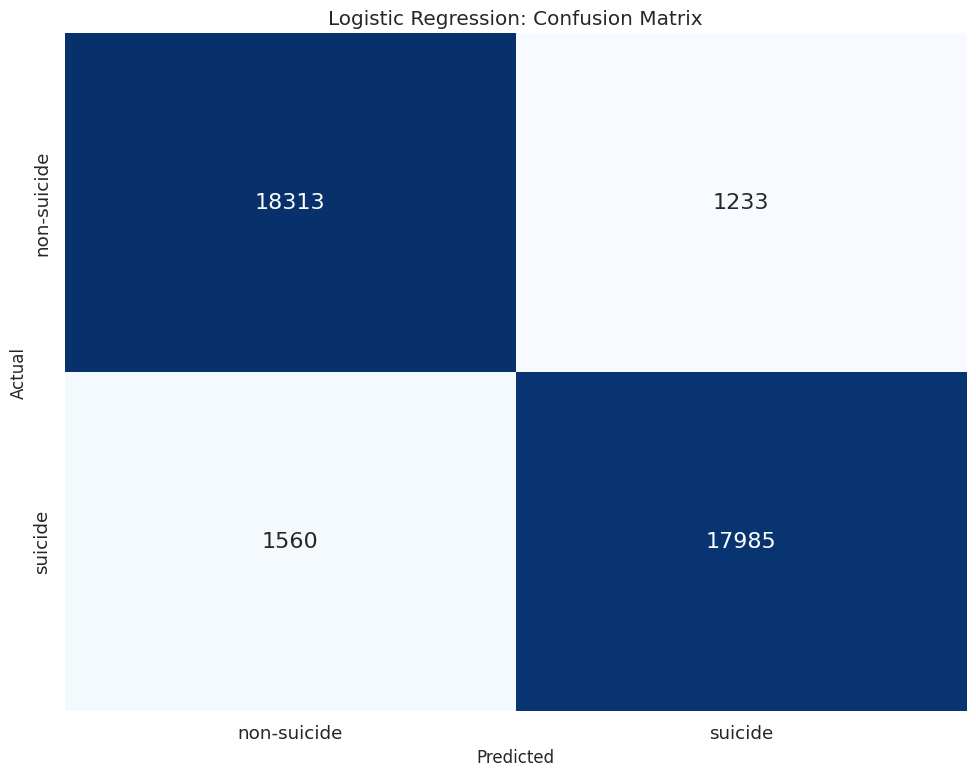

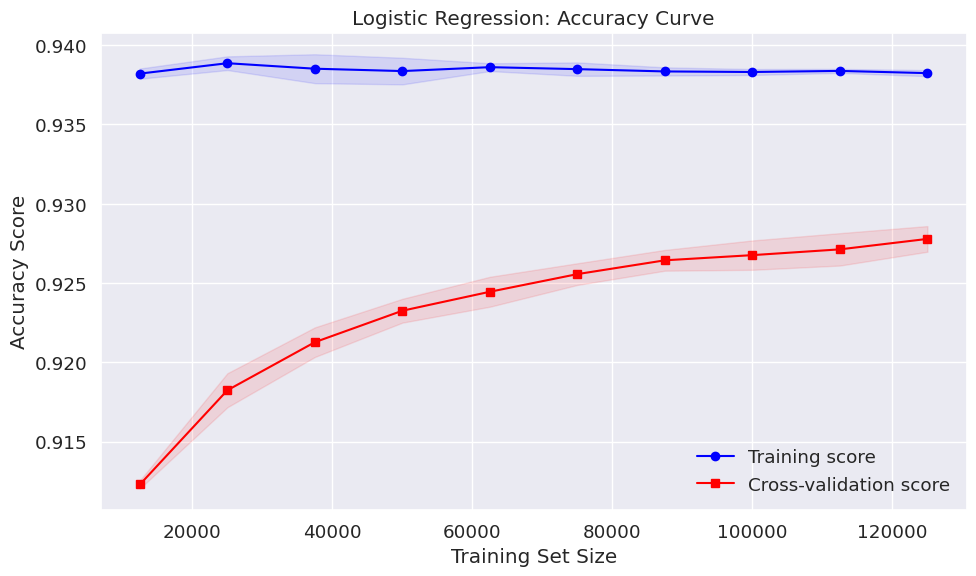

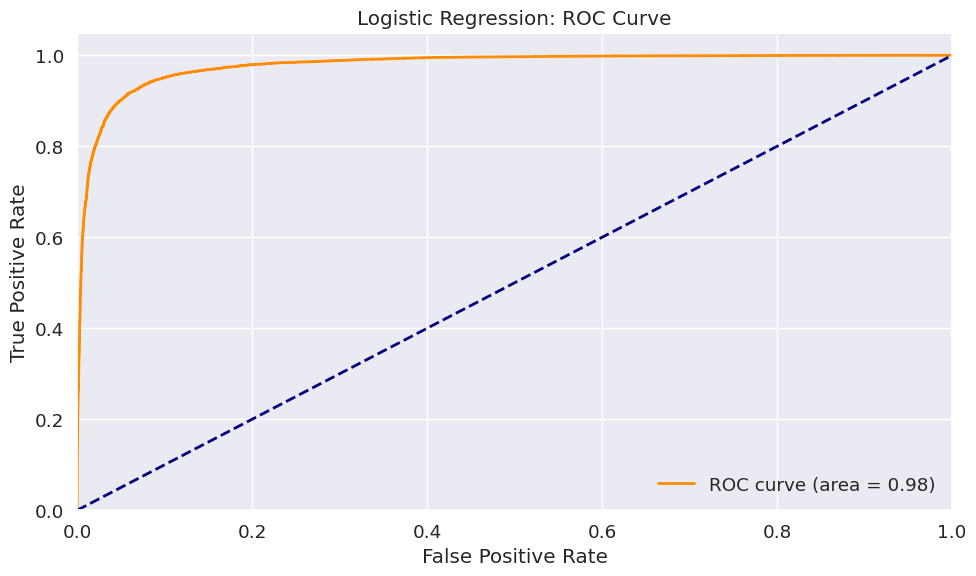

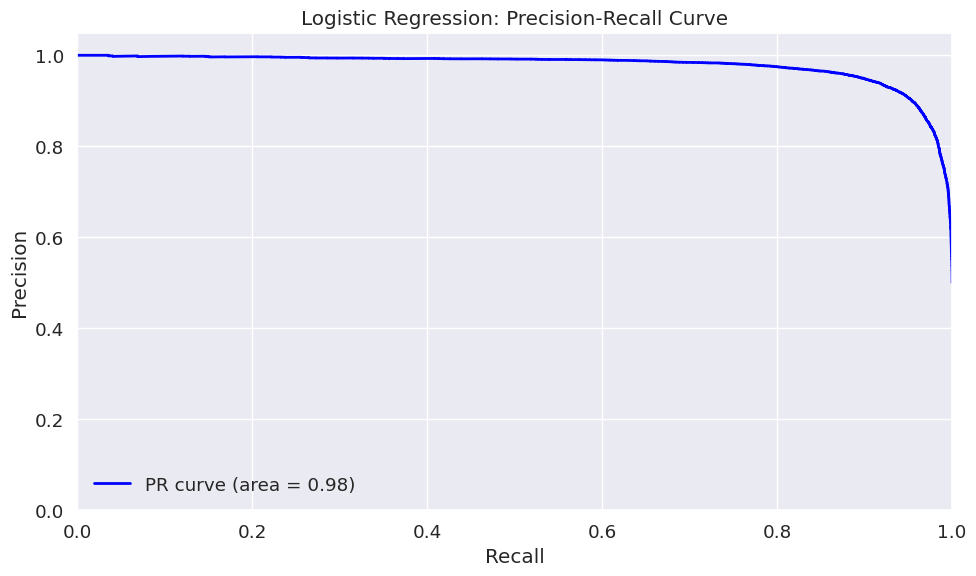


Saving model and vectorizer...
Model and vectorizer saved successfully.


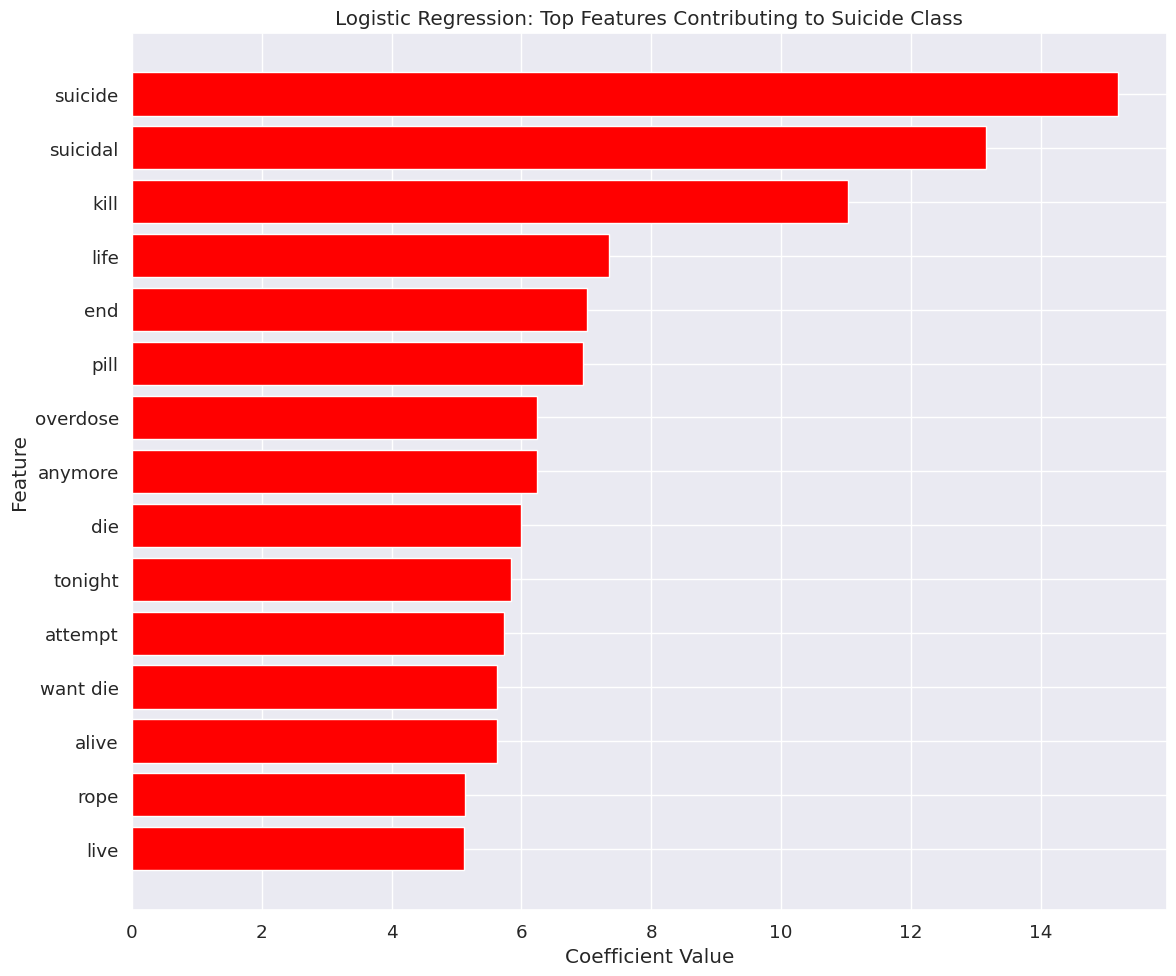

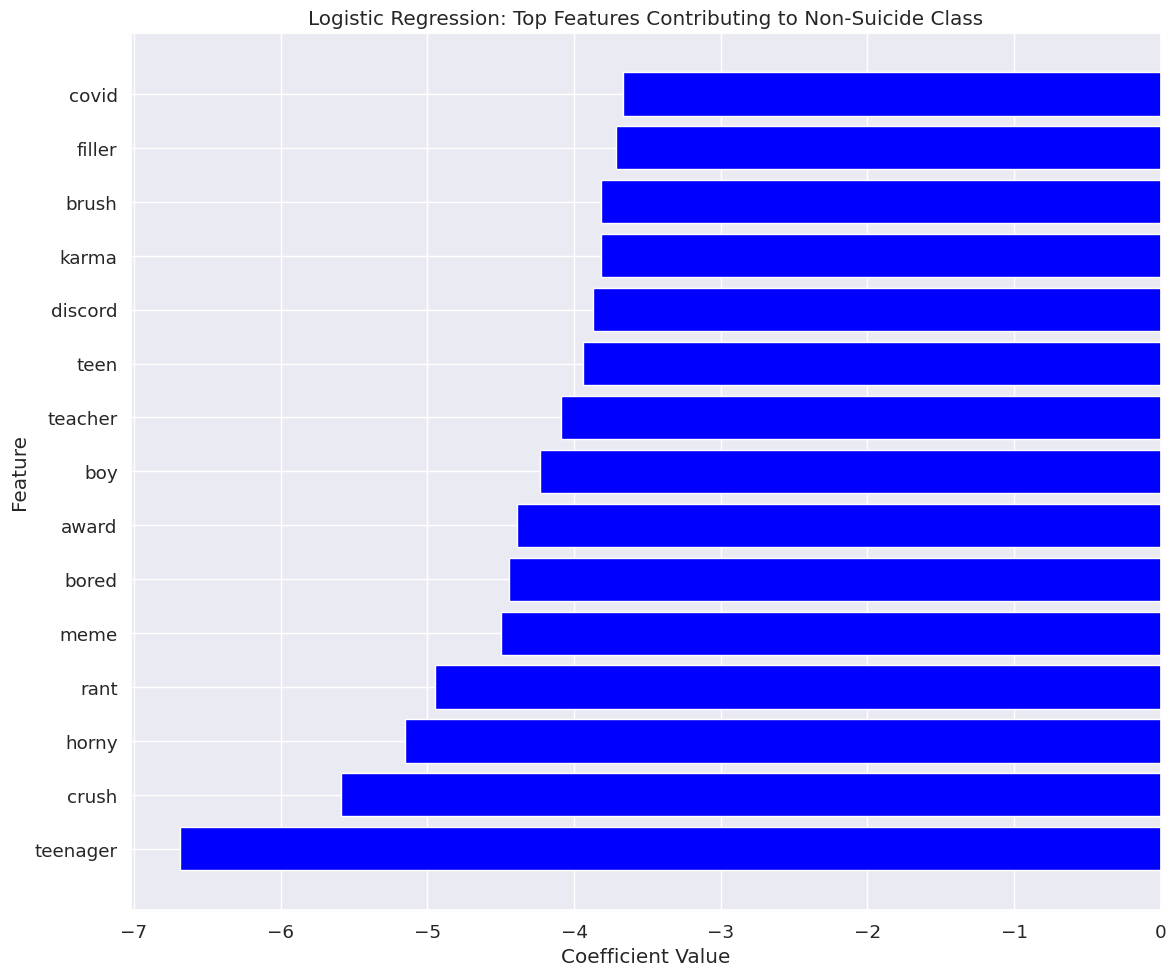


Model training and evaluation complete.


In [9]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import learning_curve
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# Set matplotlib to inline mode for Kaggle notebook
%matplotlib inline

# Step 1: Train a Logistic Regression model
print("Training Logistic Regression model...")
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)
print("Model training complete.")

# Step 2: Model Evaluation
# Make predictions
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]  # Probability estimates for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)

# Handle potential label issues - check if 'suicide' is in the class labels
if 'suicide' in clf.classes_:
    pos_label = 'suicide'
else:
    # If not, use the actual positive class label
    pos_label = clf.classes_[1]  # Assuming binary classification with second class as positive
    print(f"Note: Using '{pos_label}' as the positive class label")

precision = precision_score(y_test, y_pred, pos_label=pos_label)
recall = recall_score(y_test, y_pred, pos_label=pos_label)
f1 = f1_score(y_test, y_pred, pos_label=pos_label)

# For ROC AUC, we need to convert to binary (1/0)
target_binary = (y_test == pos_label).astype(int)
roc_auc = roc_auc_score(target_binary, y_pred_proba)

# Print evaluation metrics
print("\nModel Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC-ROC: {roc_auc:.4f}")

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix without overlapping annotations
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=clf.classes_, yticklabels=clf.classes_,
            annot_kws={"size": 16})

# Instead of overlaying text on the cells, add a title with TP, FP, TN, FN explanation
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    plt.title(f'Logistic Regression: Confusion Matrix\nTN={tn}, FP={fp}, FN={fn}, TP={tp}', 
              fontsize=14, pad=10)
else:
    plt.title('Logistic Regression: Confusion Matrix', fontsize=14)
    
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression: Confusion Matrix')
plt.tight_layout()
plt.show()

# Calculate accuracy and loss curves to check for overfitting/underfitting
# Note: For sparse matrices, we need to handle them properly
try:
    train_sizes, train_scores, test_scores = learning_curve(
        LogisticRegression(max_iter=1000, random_state=42), 
        X_train, y_train, cv=5, scoring='accuracy', 
        train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
    )
except Exception as e:
    print(f"Error generating learning curve: {e}")
    # Create dummy data in case of error
    train_sizes = np.linspace(0.1, 1.0, 10)
    train_scores = np.zeros((10, 5))
    test_scores = np.zeros((10, 5))

# Calculate mean and standard deviation for training set scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

# Calculate mean and standard deviation for test set scores
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot accuracy curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label="Training score", color="blue", marker='o')
plt.plot(train_sizes, test_mean, label="Cross-validation score", color="red", marker='s')

# Fill between the mean and standard deviation
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="red", alpha=0.1)

plt.title("Logistic Regression: Accuracy Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot ROC Curve
# Use the already created binary target variable
fpr, tpr, thresholds = roc_curve(target_binary, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression: ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Precision-Recall Curve
# Use the already created binary target variable
precision_curve, recall_curve, _ = precision_recall_curve(target_binary, y_pred_proba)
pr_auc = auc(recall_curve, precision_curve)

plt.figure(figsize=(10, 6))
plt.plot(recall_curve, precision_curve, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Logistic Regression: Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 3: Model Saving
print("\nSaving model and vectorizer...")
joblib.dump(clf, '/kaggle/working/logistic_regression_model.pkl')
joblib.dump(tfidf_vectorizer, '/kaggle/working/tfidf_vectorizer.pkl')
print("Model and vectorizer saved successfully.")

# Step 4: Plot top features
def plot_top_features(model, feature_names, top_n=20, class_to_show=None):
    """Plot the top features based on the model coefficients."""
    # If no specific class is provided, use the second class (often the positive class)
    if class_to_show is None:
        class_to_show = model.classes_[1]
        print(f"Using '{class_to_show}' as the positive class for feature importance")
    
    # For binary classification
    if len(model.classes_) == 2:
        # Find which index corresponds to our target class
        try:
            class_idx = np.where(model.classes_ == class_to_show)[0][0]
            # For binary logistic regression, coef_ is shaped (1, n_features)
            # If class_idx is 1, use coefficients as is (positive values contribute to class 1)
            # If class_idx is 0, negate coefficients (negative values contribute to class 0)
            coefficients = model.coef_[0] if class_idx == 1 else -model.coef_[0]
        except (IndexError, ValueError):
            # If class not found, default to the first class
            print(f"Warning: Class '{class_to_show}' not found in model classes. Using coefficients as is.")
            coefficients = model.coef_[0]
    else:
        # For multiclass
        try:
            class_idx = np.where(model.classes_ == class_to_show)[0][0]
            coefficients = model.coef_[class_idx]
        except (IndexError, ValueError):
            # If class not found, default to the first class
            print(f"Warning: Class '{class_to_show}' not found in model classes. Using first class.")
            coefficients = model.coef_[0]
    
    # Get the indices of the top features
    top_positive_idx = np.argsort(coefficients)[-top_n:]
    top_negative_idx = np.argsort(coefficients)[:top_n]
    
    # Get the feature names and coefficients
    top_positive_features = [feature_names[i] for i in top_positive_idx]
    top_positive_coef = [coefficients[i] for i in top_positive_idx]
    
    top_negative_features = [feature_names[i] for i in top_negative_idx]
    top_negative_coef = [coefficients[i] for i in top_negative_idx]
    
    # Plot positive features (contributes to suicide class)
    plt.figure(figsize=(12, 10))
    plt.barh(top_positive_features, top_positive_coef, color='red')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Feature')
    plt.title(f'Logistic Regression: Top Features Contributing to Suicide Class')
    plt.tight_layout()
    plt.show()
    
    # Plot negative features (contributes to non-suicide class)
    plt.figure(figsize=(12, 10))
    plt.barh(top_negative_features, top_negative_coef, color='blue')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Feature')
    plt.title(f'Logistic Regression: Top Features Contributing to Non-Suicide Class')
    plt.tight_layout()
    plt.show()

# Get feature names from TF-IDF vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# Plot top features
try:
    # Use the same positive label we identified earlier
    plot_top_features(clf, feature_names, top_n=15, class_to_show=pos_label)
except Exception as e:
    print(f"Error plotting top features: {e}")
    print("This is usually caused by mismatched dimensions or class label issues.")

print("\nModel training and evaluation complete.")

# Naïve Bayes Classifier

Training Naïve Bayes model...
Model training complete.

Model Evaluation Metrics:
Accuracy: 0.9053
Precision: 0.8842
Recall: 0.9327
F1-score: 0.9078
AUC-ROC: 0.9678

Classification Report:
              precision    recall  f1-score   support

 non-suicide       0.93      0.88      0.90     19546
     suicide       0.88      0.93      0.91     19545

    accuracy                           0.91     39091
   macro avg       0.91      0.91      0.91     39091
weighted avg       0.91      0.91      0.91     39091



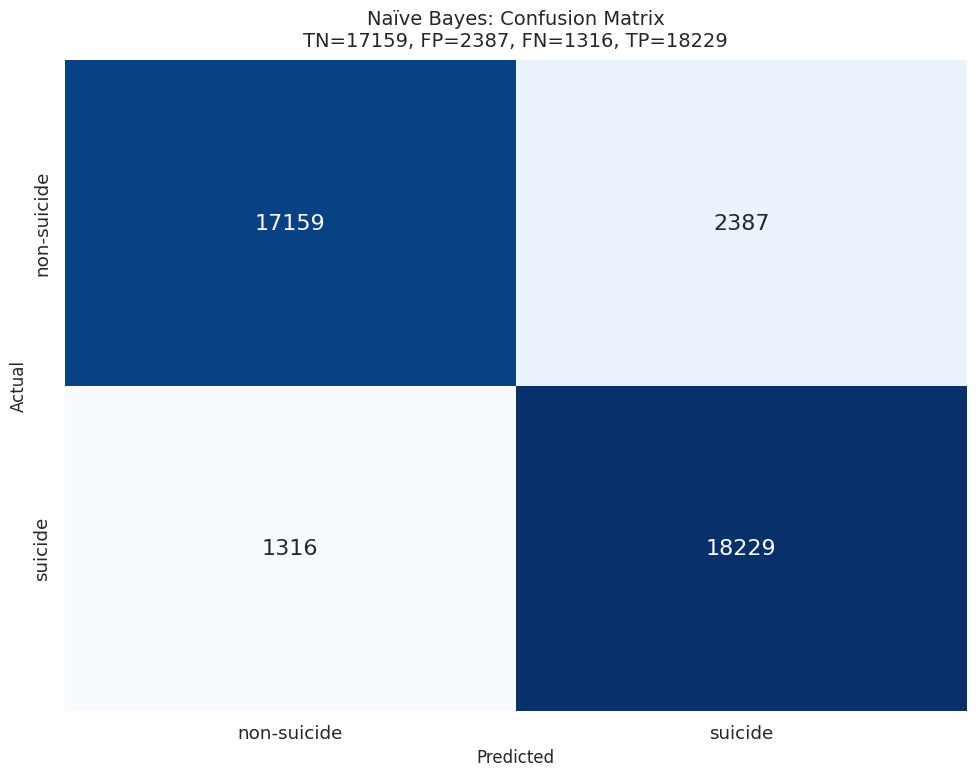

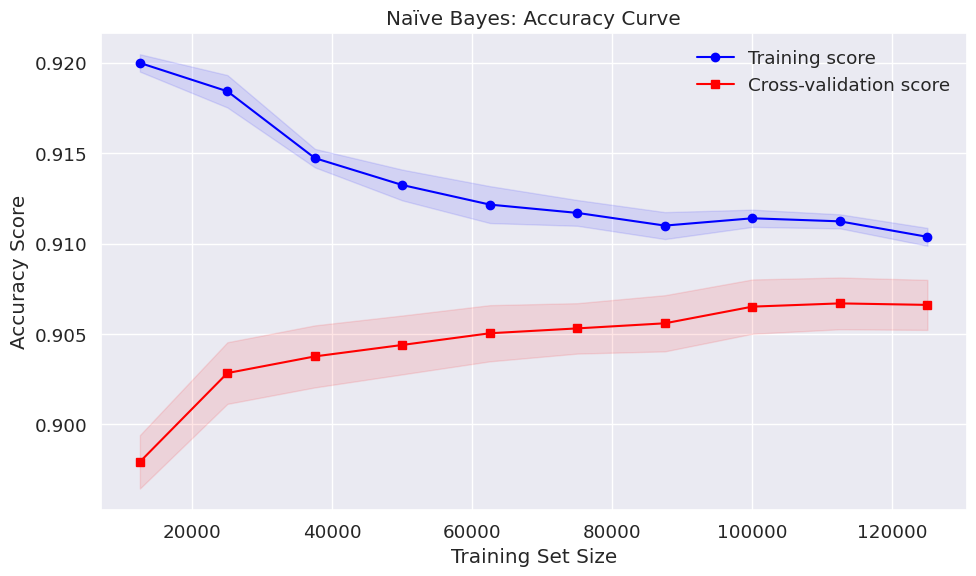

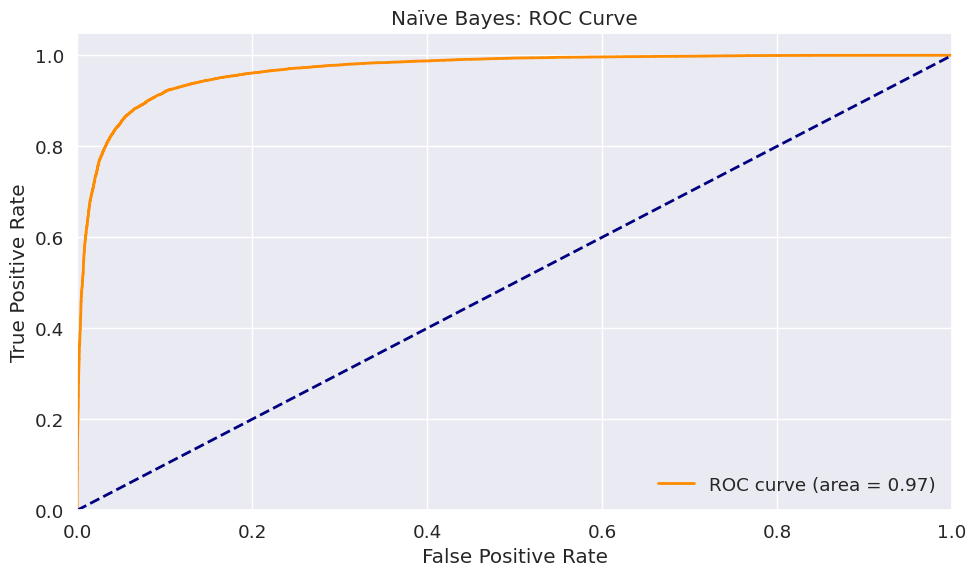

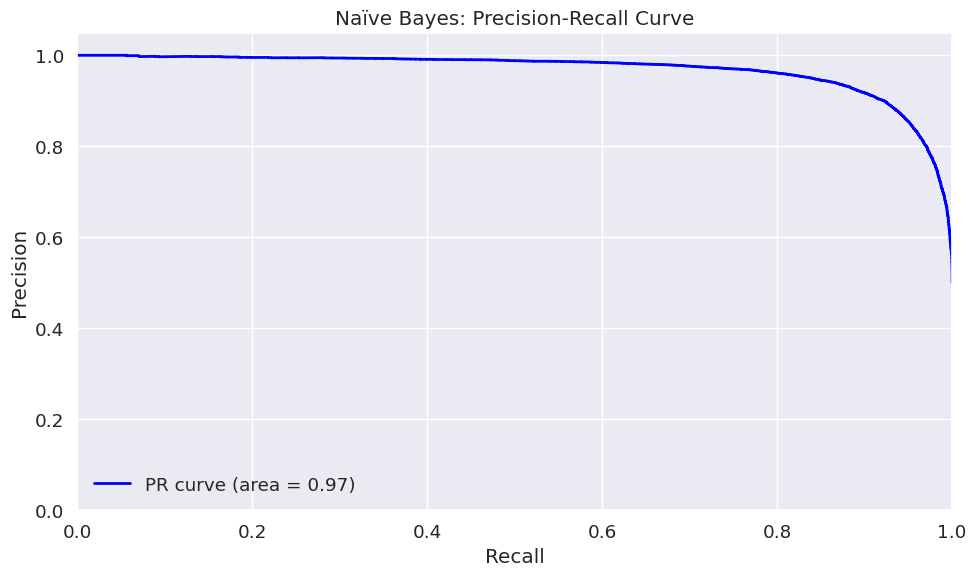


Saving model and vectorizer...
Model and vectorizer saved successfully.


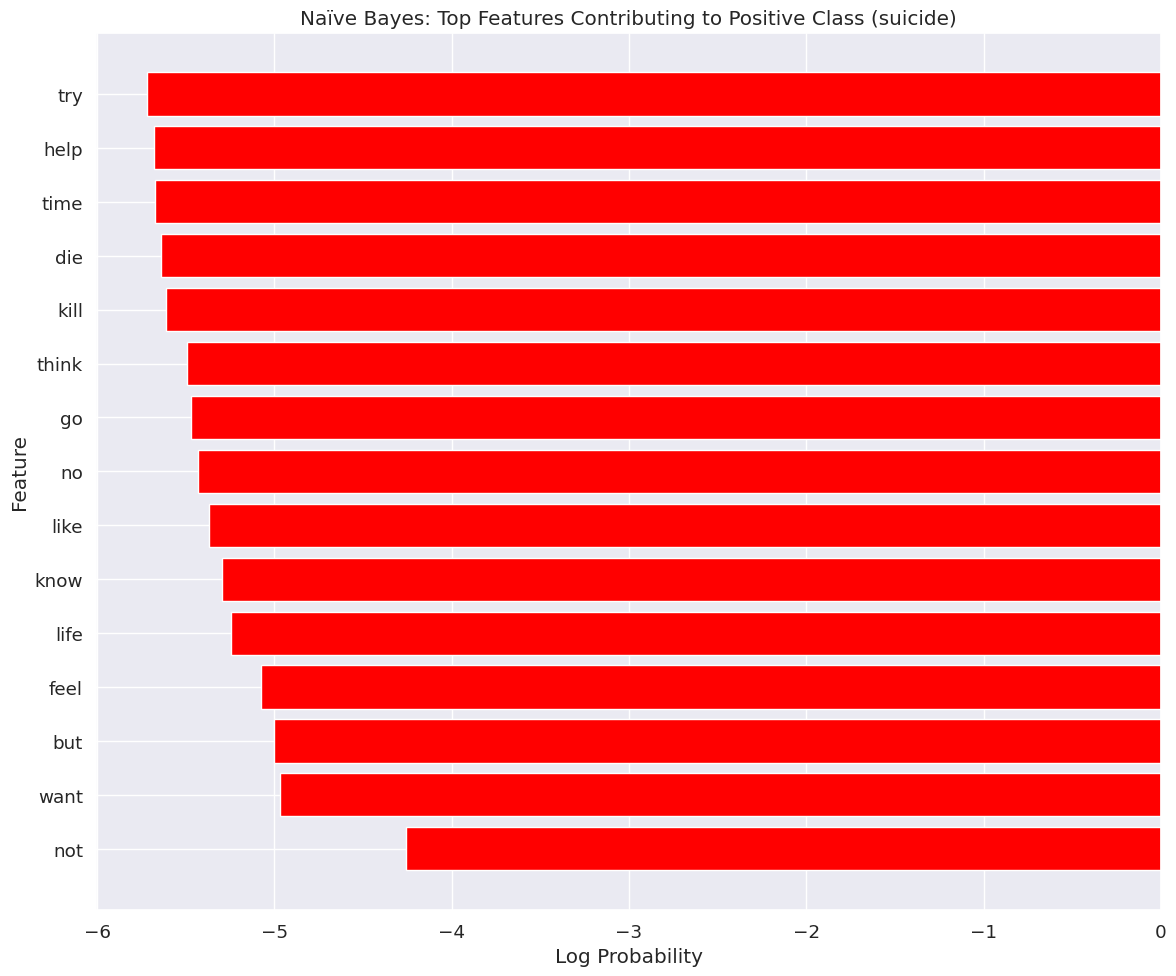

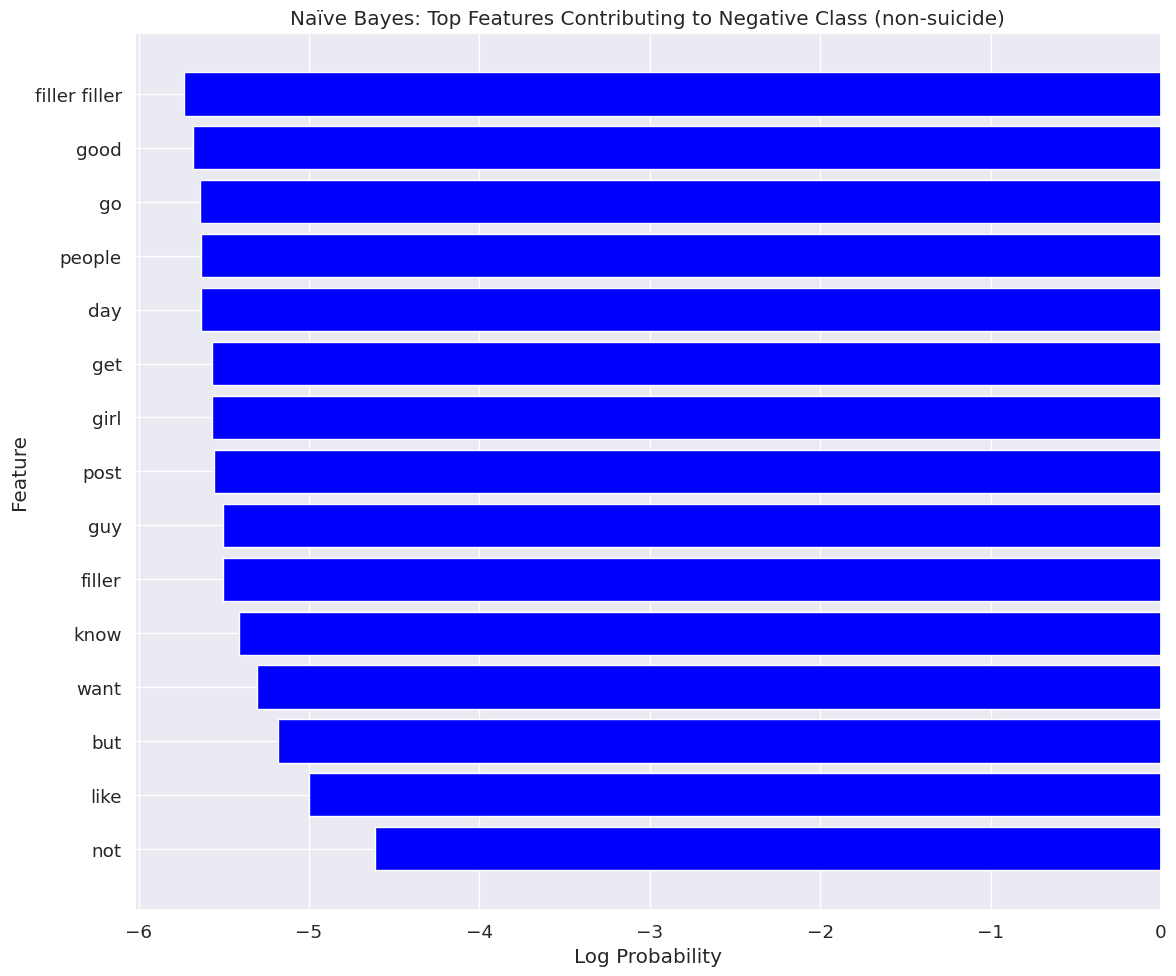


Naïve Bayes model training and evaluation complete.


In [10]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import learning_curve
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# Set matplotlib to inline mode for Kaggle notebook
%matplotlib inline

# Step 1: Train a Naïve Bayes model
print("Training Naïve Bayes model...")
nb_model = MultinomialNB(alpha=1.0, fit_prior=True)
nb_model.fit(X_train, y_train)
print("Model training complete.")

# Step 2: Model Evaluation
# Make predictions
y_pred = nb_model.predict(X_test)
y_pred_proba = nb_model.predict_proba(X_test)[:, 1]  # Probability estimates for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)

# Handle potential label issues - check class labels
if 'suicide' in nb_model.classes_:
    pos_label = 'suicide'
else:
    # If not, use the actual positive class label
    pos_label = nb_model.classes_[1]  # Assuming binary classification with second class as positive
    print(f"Note: Using '{pos_label}' as the positive class label")

precision = precision_score(y_test, y_pred, pos_label=pos_label)
recall = recall_score(y_test, y_pred, pos_label=pos_label)
f1 = f1_score(y_test, y_pred, pos_label=pos_label)

# For ROC AUC, we need to convert to binary (1/0)
target_binary = (y_test == pos_label).astype(int)
roc_auc = roc_auc_score(target_binary, y_pred_proba)

# Print evaluation metrics
print("\nModel Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC-ROC: {roc_auc:.4f}")

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix without overlapping annotations
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=nb_model.classes_, yticklabels=nb_model.classes_,
            annot_kws={"size": 16})

# Instead of overlaying text on the cells, add a title with TP, FP, TN, FN explanation
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    plt.title(f'Naïve Bayes: Confusion Matrix\nTN={tn}, FP={fp}, FN={fn}, TP={tp}', 
              fontsize=14, pad=10)
else:
    plt.title('Naïve Bayes: Confusion Matrix', fontsize=14)
    
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

# Calculate accuracy and loss curves to check for overfitting/underfitting
# Note: For sparse matrices, we need to handle them properly
try:
    train_sizes, train_scores, test_scores = learning_curve(
        MultinomialNB(alpha=1.0, fit_prior=True), 
        X_train, y_train, cv=5, scoring='accuracy', 
        train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
    )
except Exception as e:
    print(f"Error generating learning curve: {e}")
    # Create dummy data in case of error
    train_sizes = np.linspace(0.1, 1.0, 10)
    train_scores = np.zeros((10, 5))
    test_scores = np.zeros((10, 5))

# Calculate mean and standard deviation for training set scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

# Calculate mean and standard deviation for test set scores
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot accuracy curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label="Training score", color="blue", marker='o')
plt.plot(train_sizes, test_mean, label="Cross-validation score", color="red", marker='s')

# Fill between the mean and standard deviation
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="red", alpha=0.1)

plt.title("Naïve Bayes: Accuracy Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(target_binary, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Naïve Bayes: ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Precision-Recall Curve
precision_curve, recall_curve, _ = precision_recall_curve(target_binary, y_pred_proba)
pr_auc = auc(recall_curve, precision_curve)

plt.figure(figsize=(10, 6))
plt.plot(recall_curve, precision_curve, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Naïve Bayes: Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 3: Model Saving
print("\nSaving model and vectorizer...")
joblib.dump(nb_model, '/kaggle/working/naive_bayes_model.pkl')
joblib.dump(tfidf_vectorizer, '/kaggle/working/tfidf_vectorizer_nb.pkl')
print("Model and vectorizer saved successfully.")

# Step 4: Plot top features
def plot_top_features(nb_model, feature_names, top_n=20):
    """Plot the top features based on the Naive Bayes model's feature log probabilities."""
    
    # Get the number of classes and features
    n_classes = len(nb_model.classes_)
    n_features = len(feature_names)
    
    # Find the index of the positive class (suicide or equivalent)
    if 'suicide' in nb_model.classes_:
        pos_idx = np.where(nb_model.classes_ == 'suicide')[0][0]
    else:
        pos_idx = 1  # Default to the second class as positive
        
    # Get the log probabilities for each feature for our positive class
    feature_log_probs = nb_model.feature_log_prob_[pos_idx]
    
    # Get the indices of the top features
    top_indices = np.argsort(feature_log_probs)[-top_n:]
    
    # Get the feature names and log probabilities
    top_features = [feature_names[i] for i in top_indices]
    top_log_probs = [feature_log_probs[i] for i in top_indices]
    
    # Reverse the order for better visualization (highest on top)
    top_features.reverse()
    top_log_probs.reverse()
    
    # Plot positive features (contributes to suicide class)
    plt.figure(figsize=(12, 10))
    plt.barh(top_features, top_log_probs, color='red')
    plt.xlabel('Log Probability')
    plt.ylabel('Feature')
    plt.title(f'Naïve Bayes: Top Features Contributing to Positive Class ({nb_model.classes_[pos_idx]})')
    plt.tight_layout()
    plt.show()
    
    # Now do the same for the negative class
    neg_idx = 0 if pos_idx == 1 else 1
    
    # Get the log probabilities for each feature for the negative class
    feature_log_probs_neg = nb_model.feature_log_prob_[neg_idx]
    
    # Get the indices of the top features
    top_indices_neg = np.argsort(feature_log_probs_neg)[-top_n:]
    
    # Get the feature names and log probabilities
    top_features_neg = [feature_names[i] for i in top_indices_neg]
    top_log_probs_neg = [feature_log_probs_neg[i] for i in top_indices_neg]
    
    # Reverse the order for better visualization (highest on top)
    top_features_neg.reverse()
    top_log_probs_neg.reverse()
    
    # Plot negative features
    plt.figure(figsize=(12, 10))
    plt.barh(top_features_neg, top_log_probs_neg, color='blue')
    plt.xlabel('Log Probability')
    plt.ylabel('Feature')
    plt.title(f'Naïve Bayes: Top Features Contributing to Negative Class ({nb_model.classes_[neg_idx]})')
    plt.tight_layout()
    plt.show()

# Get feature names from TF-IDF vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# Plot top features
try:
    plot_top_features(nb_model, feature_names, top_n=15)
except Exception as e:
    print(f"Error plotting top features: {e}")
    print("This is usually caused by mismatched dimensions or class label issues.")

print("\nNaïve Bayes model training and evaluation complete.")

# Support Vector Machine (SVM)

Starting SVM model training and evaluation...

Training Support Vector Machine model...
Model training complete.

Model Evaluation Metrics:
Accuracy: 0.9283
Precision: 0.9346
Recall: 0.9212
F1-score: 0.9278
AUC-ROC: 0.9785

Classification Report:
              precision    recall  f1-score   support

 non-suicide       0.92      0.94      0.93     19546
     suicide       0.93      0.92      0.93     19545

    accuracy                           0.93     39091
   macro avg       0.93      0.93      0.93     39091
weighted avg       0.93      0.93      0.93     39091



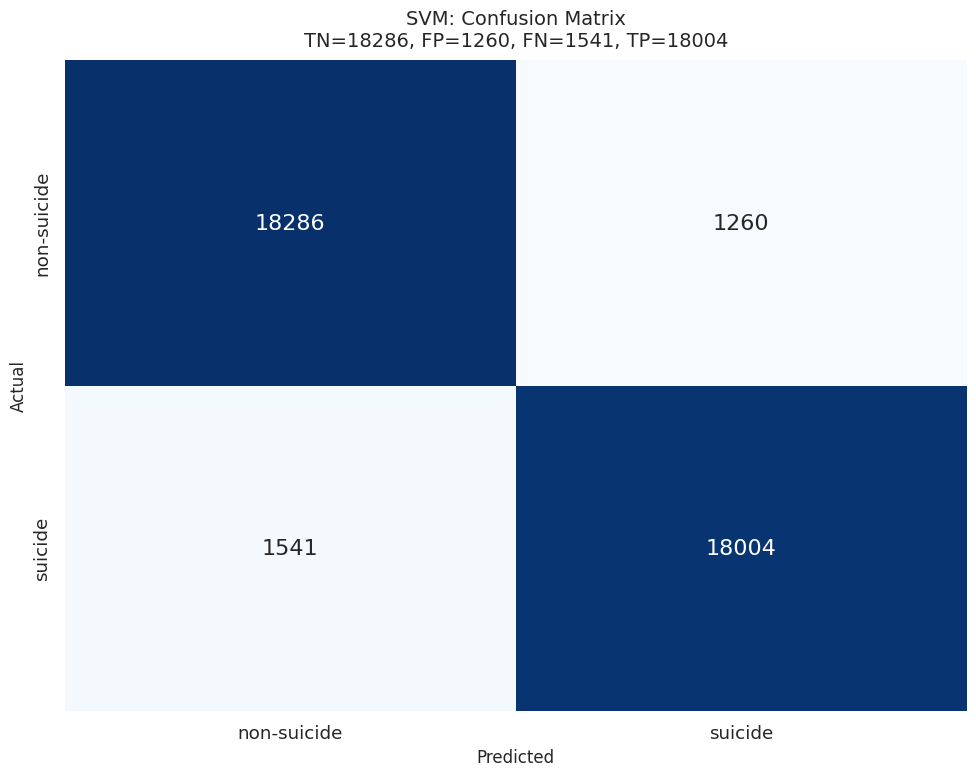


Generating learning curves...
Using 2000 samples for learning curve (out of 156363 total)


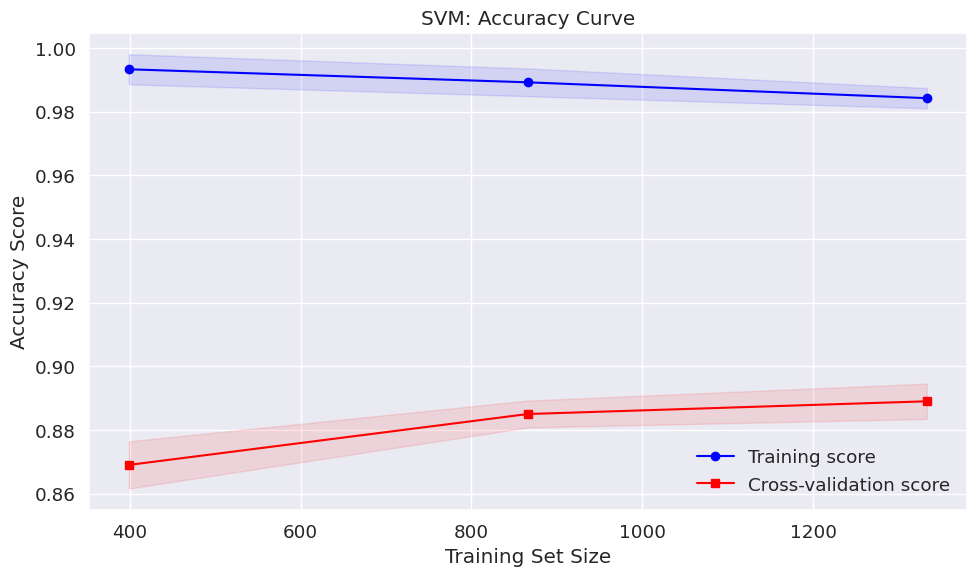

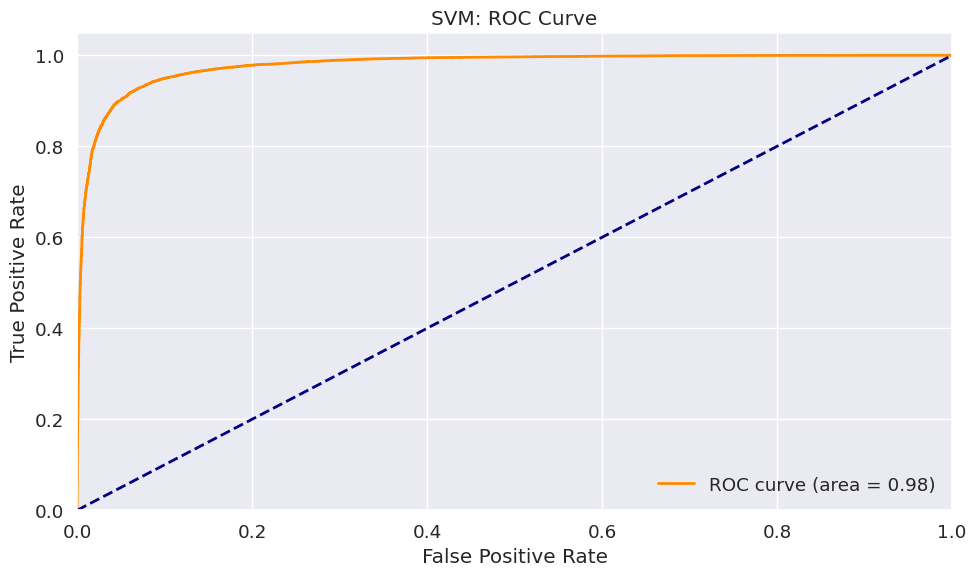

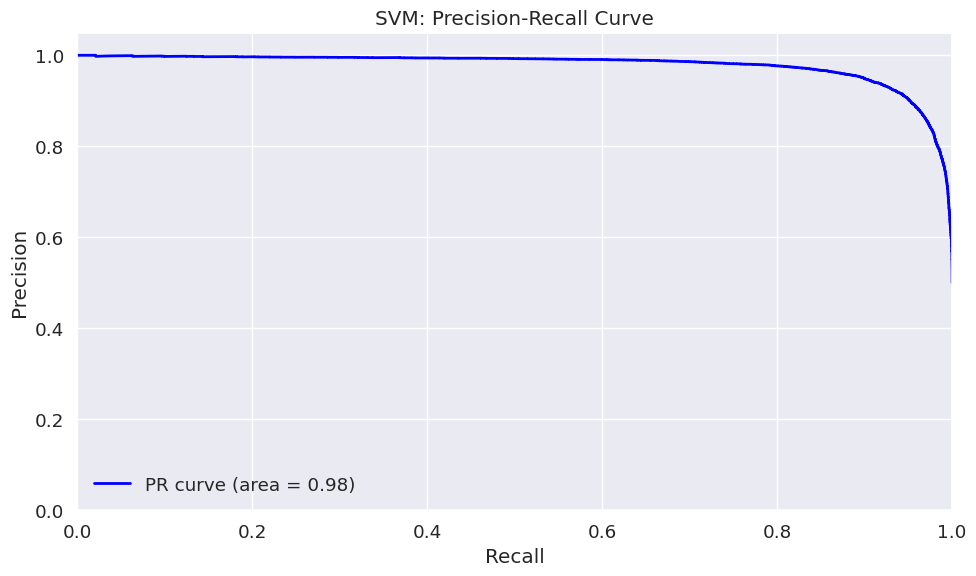


Saving model and vectorizer...
Model and vectorizer saved successfully.

Extracting and visualizing feature importance...
Error extracting feature importance: '_CalibratedClassifier' object has no attribute 'base_estimator'

SVM model training and evaluation complete.


In [14]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import learning_curve
import warnings
import gc  # Garbage collection for memory management
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# Set matplotlib to inline mode for Kaggle notebook
%matplotlib inline

# Memory optimization - run garbage collection
gc.collect()

print("Starting SVM model training and evaluation...")

# Step 1: Train an SVM model
print("\nTraining Support Vector Machine model...")
# Use a more memory-efficient configuration
# Linear SVC is more efficient than SVC for large datasets with text features
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# First create a base linear SVC model (faster but doesn't support probability estimates)
base_svm = LinearSVC(C=1, random_state=42, max_iter=1000)
# Then wrap it with CalibratedClassifierCV to get probability estimates
svm_model = CalibratedClassifierCV(base_svm, cv=3)

# Train the SVM model
try:
    svm_model.fit(X_train, y_train)
    print("Model training complete.")
except Exception as e:
    print(f"Error during model training: {e}")
    print("Attempting to train with a smaller subset...")
    # Try with a smaller subset if full training fails
    sample_size = min(10000, X_train.shape[0])
    if sample_size < X_train.shape[0]:
        indices = np.random.choice(X_train.shape[0], sample_size, replace=False)
        X_train_subset = X_train[indices]
        y_train_subset = y_train.iloc[indices] if hasattr(y_train, 'iloc') else y_train[indices]
        svm_model.fit(X_train_subset, y_train_subset)
        print(f"Model trained successfully on {sample_size} samples.")
    else:
        raise Exception("Unable to train model even with reduced sample size.")

# Step 2: Model Evaluation
# Make predictions
y_pred = svm_model.predict(X_test)
y_pred_proba = svm_model.predict_proba(X_test)[:, 1]  # Probability estimates for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)

# Handle potential label issues - check class labels
if 'suicide' in svm_model.classes_:
    pos_label = 'suicide'
else:
    # If not, use the actual positive class label
    pos_label = svm_model.classes_[1]  # Assuming binary classification with second class as positive
    print(f"Note: Using '{pos_label}' as the positive class label")

precision = precision_score(y_test, y_pred, pos_label=pos_label)
recall = recall_score(y_test, y_pred, pos_label=pos_label)
f1 = f1_score(y_test, y_pred, pos_label=pos_label)

# For ROC AUC, we need to convert to binary (1/0)
target_binary = (y_test == pos_label).astype(int)
roc_auc = roc_auc_score(target_binary, y_pred_proba)

# Print evaluation metrics
print("\nModel Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC-ROC: {roc_auc:.4f}")

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix without overlapping annotations
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_,
            annot_kws={"size": 16})

# Instead of overlaying text on the cells, add a title with TP, FP, TN, FN explanation
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    plt.title(f'SVM: Confusion Matrix\nTN={tn}, FP={fp}, FN={fn}, TP={tp}', 
              fontsize=14, pad=10)
else:
    plt.title('SVM: Confusion Matrix', fontsize=14)
    
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

# Calculate accuracy and loss curves to check for overfitting/underfitting
# Note: For sparse matrices and large datasets, we need to handle them carefully
print("\nGenerating learning curves...")
try:
    # Use a much smaller subset for learning curve to avoid memory issues with SVM
    # On Kaggle, memory constraints can be strict
    sample_size = min(2000, X_train.shape[0])
    if sample_size < X_train.shape[0]:
        print(f"Using {sample_size} samples for learning curve (out of {X_train.shape[0]} total)")
    
    # Create a smaller subset of the training data
    indices = np.random.choice(X_train.shape[0], sample_size, replace=False)
    X_train_subset = X_train[indices]
    y_train_subset = y_train.iloc[indices] if hasattr(y_train, 'iloc') else y_train[indices]
    
    # Calculate learning curve with fewer splits and samples
    train_sizes, train_scores, test_scores = learning_curve(
        SVC(kernel='linear', probability=True, random_state=42), 
        X_train_subset, y_train_subset, 
        cv=3,  # Reduced from 5 to 3
        scoring='accuracy', 
        train_sizes=np.linspace(0.3, 1.0, 3)  # Reduced number of points
    )
    
    # Calculate mean and standard deviation for training set scores
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)

    # Calculate mean and standard deviation for test set scores
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Plot accuracy curve
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, label="Training score", color="blue", marker='o')
    plt.plot(train_sizes, test_mean, label="Cross-validation score", color="red", marker='s')

    # Fill between the mean and standard deviation
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.1)
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="red", alpha=0.1)

    plt.title("SVM: Accuracy Curve")
    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy Score")
    plt.legend(loc="best")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"Warning: Could not generate learning curves: {e}")
    print("This is usually due to memory constraints with SVM on large datasets.")
    print("Continuing with other evaluations...")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(target_binary, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM: ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Precision-Recall Curve
precision_curve, recall_curve, _ = precision_recall_curve(target_binary, y_pred_proba)
pr_auc = auc(recall_curve, precision_curve)

plt.figure(figsize=(10, 6))
plt.plot(recall_curve, precision_curve, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('SVM: Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 3: Model Saving
print("\nSaving model and vectorizer...")
joblib.dump(svm_model, '/kaggle/working/svm_model.pkl')
joblib.dump(tfidf_vectorizer, '/kaggle/working/tfidf_vectorizer_svm.pkl')
print("Model and vectorizer saved successfully.")

# Step 4: Plot top features
print("\nExtracting and visualizing feature importance...")

def plot_top_features(model, feature_names, top_n=20, class_labels=None):
    """Plot the top features based on SVM coefficients."""
    try:
        # For CalibratedClassifierCV, we need to access the base_estimator
        if hasattr(model, 'calibrated_classifiers_'):
            # Get the first calibrated classifier's base estimator
            base_model = model.calibrated_classifiers_[0].base_estimator
            if hasattr(base_model, 'coef_'):
                coefficients = base_model.coef_
            else:
                print("Base model does not have coefficient attribute.")
                return
        # For regular SVC
        elif hasattr(model, 'coef_'):
            coefficients = model.coef_
        else:
            print("Model does not have coefficients attribute. Cannot extract feature importance.")
            return
            
        # Convert coefficients to dense array if they're sparse
        if hasattr(coefficients, 'toarray'):
            coefficients = coefficients.toarray()
                
        # Handle dimensionality
        if len(coefficients.shape) == 2 and coefficients.shape[0] == 1:
            importance = abs(coefficients[0])
            coef = coefficients[0]  # To get sign
        else:
            # For the positive class
            if class_labels is not None and len(class_labels) > 1:
                pos_idx = 1
                if 'suicide' in class_labels:
                    pos_idx = np.where(class_labels == 'suicide')[0][0]
                importance = abs(coefficients[pos_idx])
                coef = coefficients[pos_idx]  # To get sign
            else:
                importance = abs(coefficients[0])
                coef = coefficients[0]
                
        # Get indices of top features
        top_indices = np.argsort(importance)[-top_n:]
        
        # Get top features and their importances
        top_features = [feature_names[i] for i in top_indices]
        top_importance = [importance[i] for i in top_indices]
        top_coef = [coef[i] for i in top_indices]
        
        # Reverse for better visualization
        top_features.reverse()
        top_importance.reverse()
        top_coef.reverse()
        
        # Create color list based on coefficient sign
        colors = ['green' if c > 0 else 'red' for c in top_coef]
        
        # Plot
        plt.figure(figsize=(12, 10))
        bars = plt.barh(top_features, top_importance, color=colors)
        plt.xlabel('Coefficient Magnitude')
        plt.ylabel('Feature')
        plt.title(f'SVM: Top Feature Importance')
        
        # Add a legend for positive and negative impact
        pos_patch = plt.Rectangle((0, 0), 1, 1, fc="green")
        neg_patch = plt.Rectangle((0, 0), 1, 1, fc="red")
        plt.legend([pos_patch, neg_patch], ['Positive Impact (Suicide)', 'Negative Impact (Non-Suicide)'])
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error extracting feature importance: {e}")

# Get feature names from TF-IDF vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# Plot top features
try:
    plot_top_features(svm_model, feature_names, top_n=15, class_labels=svm_model.classes_)
except Exception as e:
    print(f"Error plotting top features: {e}")
    print("This is usually caused by memory issues or class label formatting.")

print("\nSVM model training and evaluation complete.")

# Random Forest

Starting Random Forest model training and evaluation...

Training Random Forest model...
Fitting the model to training data...
Model training complete.

Evaluating model performance...

Model Evaluation Metrics:
Accuracy: 0.9010
Precision: 0.8927
Recall: 0.9116
F1-score: 0.9021
AUC-ROC: 0.9619

Classification Report:
              precision    recall  f1-score   support

 non-suicide       0.91      0.89      0.90     19546
     suicide       0.89      0.91      0.90     19545

    accuracy                           0.90     39091
   macro avg       0.90      0.90      0.90     39091
weighted avg       0.90      0.90      0.90     39091



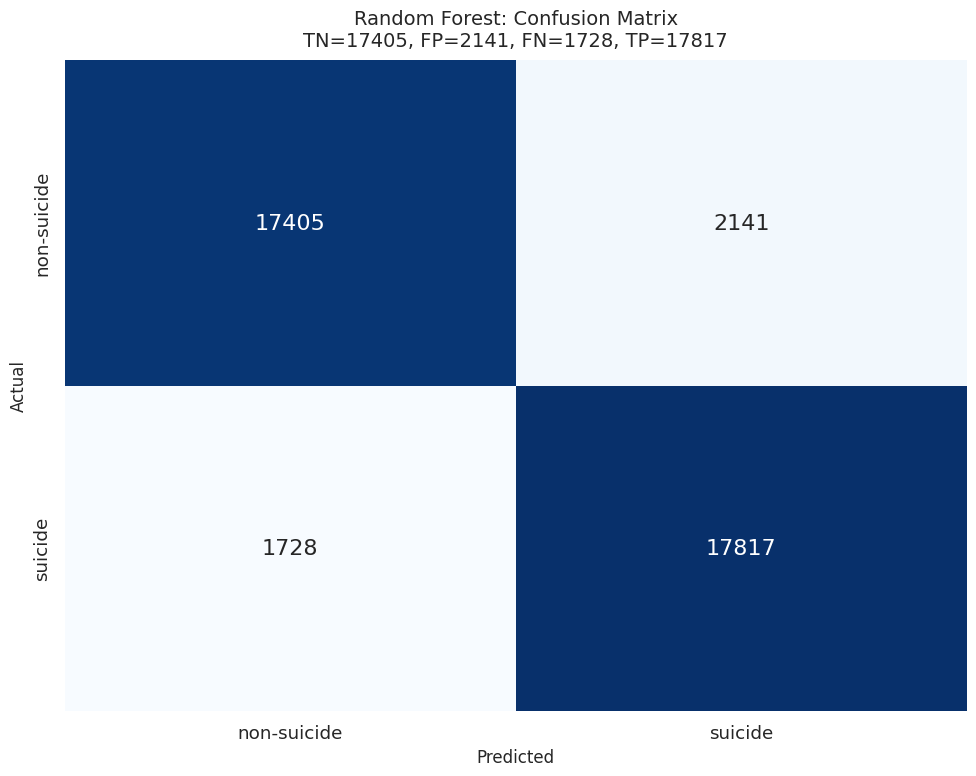


Plotting feature importance...


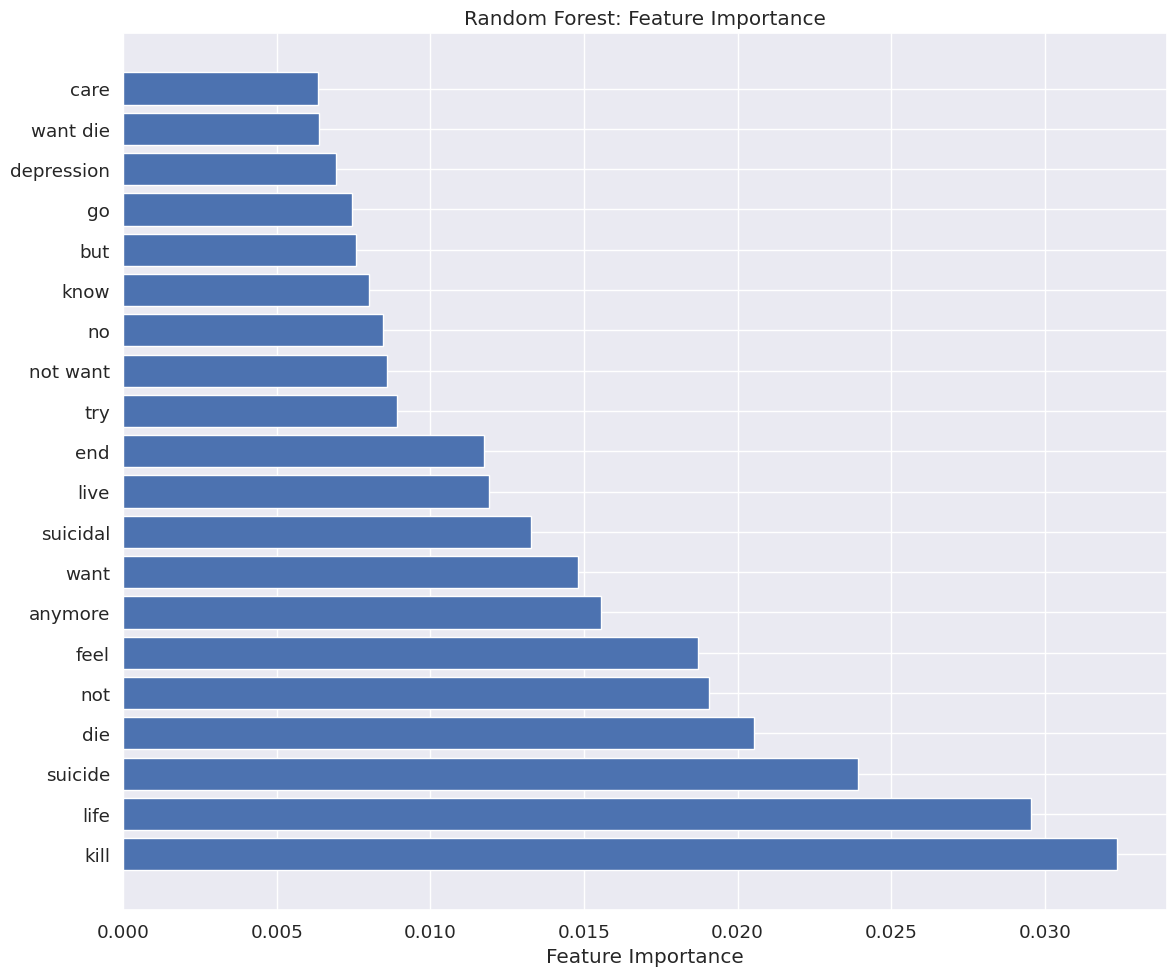


Generating learning curves...
Using 5000 samples for learning curve (out of 156363 total)


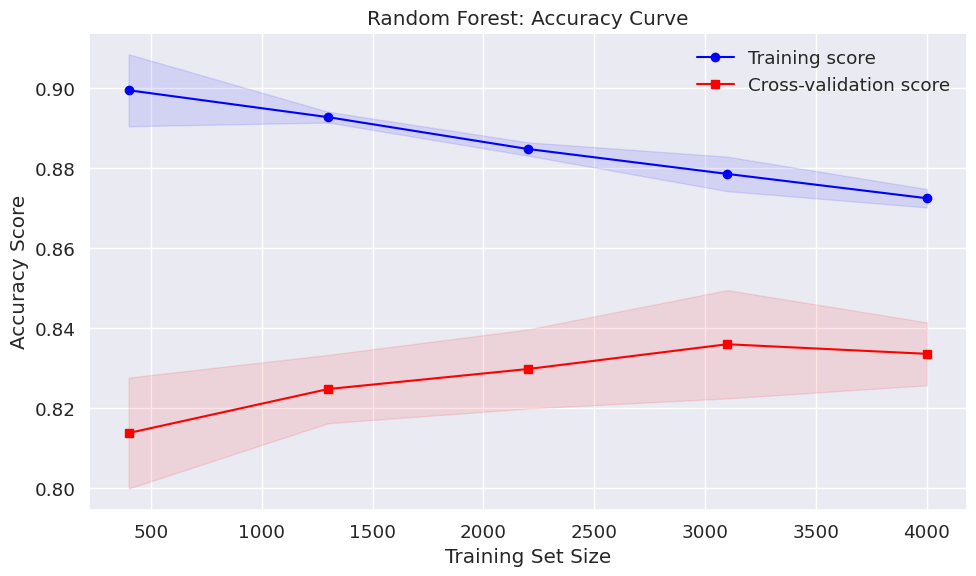


Plotting ROC curve...


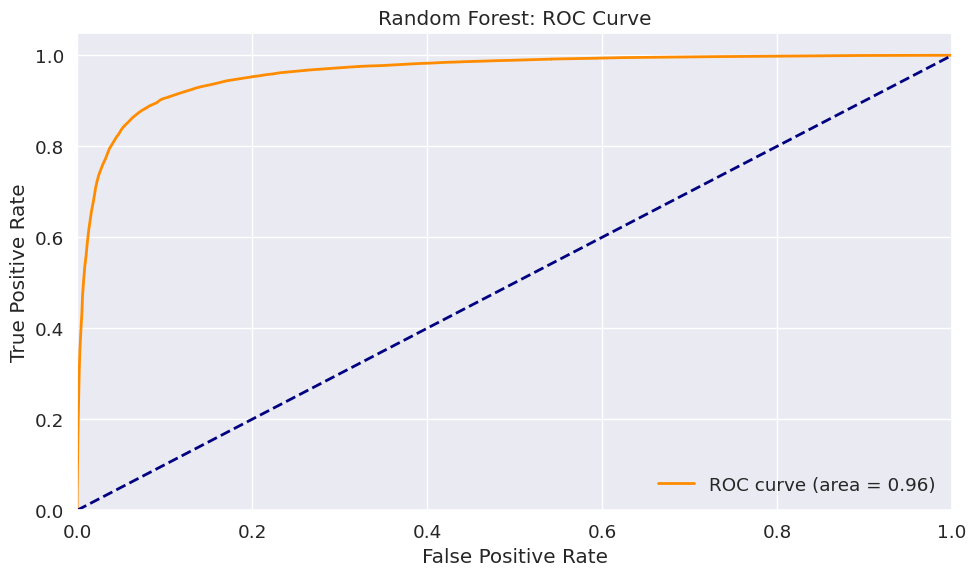


Plotting Precision-Recall curve...


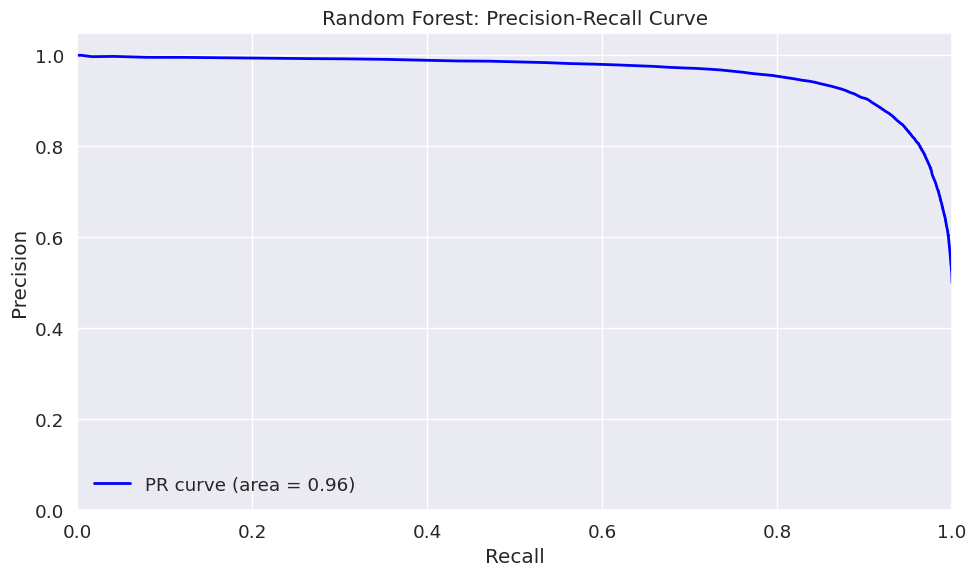


Saving model and vectorizer...
Model and vectorizer saved successfully.

Random Forest model training and evaluation complete.


In [13]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import learning_curve
import warnings
import gc  # Garbage collection for memory management
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# Set matplotlib to inline mode for Kaggle notebook
%matplotlib inline

# Memory optimization - run garbage collection
gc.collect()

print("Starting Random Forest model training and evaluation...")

# Step 1: Train a Random Forest model
print("\nTraining Random Forest model...")
# Create Random Forest model with specified parameters
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1,  # Use all available CPU cores
    verbose=0   # Reduce verbosity to avoid cluttering the output
)

# Optional: Uncomment for grid search (takes longer to run)
"""
print("Performing grid search for hyperparameter tuning...")
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None]
}
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)
print(f"Best parameters found: {grid_search.best_params_}")
rf_model = grid_search.best_estimator_
"""

# Train the Random Forest model
print("Fitting the model to training data...")
try:
    rf_model.fit(X_train, y_train)
    print("Model training complete.")
except Exception as e:
    print(f"Error during model training: {e}")
    print("Attempting to train with a smaller subset...")
    # Try with a smaller subset if full training fails
    sample_size = min(10000, X_train.shape[0])
    if sample_size < X_train.shape[0]:
        indices = np.random.choice(X_train.shape[0], sample_size, replace=False)
        X_train_subset = X_train[indices]
        y_train_subset = y_train.iloc[indices] if hasattr(y_train, 'iloc') else y_train[indices]
        rf_model.fit(X_train_subset, y_train_subset)
        print(f"Model trained successfully on {sample_size} samples.")
    else:
        raise Exception("Unable to train model even with reduced sample size.")

# Step 2: Model Evaluation
print("\nEvaluating model performance...")
# Make predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]  # Probability estimates for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)

# Handle potential label issues - check class labels
if 'suicide' in rf_model.classes_:
    pos_label = 'suicide'
else:
    # If not, use the actual positive class label
    pos_label = rf_model.classes_[1]  # Assuming binary classification with second class as positive
    print(f"Note: Using '{pos_label}' as the positive class label")

precision = precision_score(y_test, y_pred, pos_label=pos_label)
recall = recall_score(y_test, y_pred, pos_label=pos_label)
f1 = f1_score(y_test, y_pred, pos_label=pos_label)

# For ROC AUC, we need to convert to binary (1/0)
target_binary = (y_test == pos_label).astype(int)
roc_auc = roc_auc_score(target_binary, y_pred_proba)

# Print evaluation metrics
print("\nModel Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC-ROC: {roc_auc:.4f}")

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix without overlapping annotations
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_,
            annot_kws={"size": 16})

# Instead of overlaying text on the cells, add a title with TP, FP, TN, FN explanation
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    plt.title(f'Random Forest: Confusion Matrix\nTN={tn}, FP={fp}, FN={fn}, TP={tp}', 
              fontsize=14, pad=10)
else:
    plt.title('Random Forest: Confusion Matrix', fontsize=14)
    
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

# Plot Feature Importance
print("\nPlotting feature importance...")
try:
    # Get feature importances from the model
    importances = rf_model.feature_importances_
    
    # Get feature names from TF-IDF vectorizer
    feature_names = tfidf_vectorizer.get_feature_names_out()
    
    # Create a DataFrame for easier sorting and handling
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    
    # Sort by importance
    feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)
    
    # Plot top 20 features
    top_n = 20
    plt.figure(figsize=(12, 10))
    plt.barh(np.arange(top_n), feature_importance_df['Importance'].values[:top_n], align='center')
    plt.yticks(np.arange(top_n), feature_importance_df['Feature'].values[:top_n])
    plt.xlabel('Feature Importance')
    plt.title('Random Forest: Feature Importance')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting feature importance: {e}")

# Calculate accuracy and loss curves to check for overfitting/underfitting
print("\nGenerating learning curves...")
try:
    # Use a smaller subset for learning curve to prevent memory issues
    sample_size = min(5000, X_train.shape[0])
    if sample_size < X_train.shape[0]:
        print(f"Using {sample_size} samples for learning curve (out of {X_train.shape[0]} total)")
    
    # Create a smaller subset of the training data
    indices = np.random.choice(X_train.shape[0], sample_size, replace=False)
    X_train_subset = X_train[indices]
    y_train_subset = y_train.iloc[indices] if hasattr(y_train, 'iloc') else y_train[indices]
    
    # Use a simpler model for learning curves
    simple_rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
    
    # Calculate learning curve
    train_sizes, train_scores, test_scores = learning_curve(
        simple_rf, X_train_subset, y_train_subset, 
        cv=5, scoring='accuracy', 
        train_sizes=np.linspace(0.1, 1.0, 5)
    )
    
    # Calculate mean and standard deviation for training set scores
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)

    # Calculate mean and standard deviation for test set scores
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Plot accuracy curve
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, label="Training score", color="blue", marker='o')
    plt.plot(train_sizes, test_mean, label="Cross-validation score", color="red", marker='s')

    # Fill between the mean and standard deviation
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.1)
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="red", alpha=0.1)

    plt.title("Random Forest: Accuracy Curve")
    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy Score")
    plt.legend(loc="best")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Warning: Could not generate learning curves: {e}")
    print("Continuing with other evaluations...")

# Plot ROC Curve
print("\nPlotting ROC curve...")
fpr, tpr, thresholds = roc_curve(target_binary, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest: ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Precision-Recall Curve
print("\nPlotting Precision-Recall curve...")
precision_curve, recall_curve, _ = precision_recall_curve(target_binary, y_pred_proba)
pr_auc = auc(recall_curve, precision_curve)

plt.figure(figsize=(10, 6))
plt.plot(recall_curve, precision_curve, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Random Forest: Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 3: Model Saving
print("\nSaving model and vectorizer...")
joblib.dump(rf_model, '/kaggle/working/random_forest_model.pkl')
joblib.dump(tfidf_vectorizer, '/kaggle/working/tfidf_vectorizer_rf.pkl')
print("Model and vectorizer saved successfully.")

print("\nRandom Forest model training and evaluation complete.")